In [53]:
#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os

#Statistical tests
import statsmodels.formula.api as smf

#Plot
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

In [54]:
directory = '../hpc_result/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [55]:
nan_rows = df[df.isna().any(axis=1)]
df.loc[df['first_success_iter'].isna(), 'attack_successful'] = False
df['first_success_iter'] = df['first_success_iter'].fillna(1000000)

In [56]:
model_counts = df['model'].value_counts()
print(model_counts)

model
mobilenet_imagenet20_adv       11808
mobilenet_imagenet20           11808
mobilenet_imagenet20_robust    11808
resnet_imagenet20_adv          11808
resnet_imagenet20              11808
resnet_imagenet20_robust       11808
swin_imagenet20_adv            11808
swin_imagenet20                11808
swin_imagenet20_robust         11808
Name: count, dtype: int64


In [57]:
df_mobilenet = df[df['model'] == 'mobilenet_imagenet20_robust'].copy()
df_resnet    = df[df['model'] == 'resnet_imagenet20_robust'].copy()
df_swin      = df[df['model'] == 'swin_imagenet20_robust'].copy()

df_mobilenet_base = df[df['model'] == 'mobilenet_imagenet20'].copy()
df_resnet_base   = df[df['model'] == 'resnet_imagenet20'].copy()
df_swin_base     = df[df['model'] == 'swin_imagenet20'].copy()

In [58]:
df_models = pd.concat([df_mobilenet, df_resnet, df_swin], ignore_index=True)
df_base = pd.concat([df_mobilenet_base, df_resnet_base, df_swin_base], ignore_index=True)

In [59]:
df_total = pd.concat([df_base,df_models],ignore_index=True)

In [60]:
df_fgsm = df_models[df_models['attack'] == 'fgsm'].copy()
df_cw    = df_models[df_models['attack'] == 'cw'].copy()
df_pgd      = df_models[df_models['attack'] == 'pgd'].copy()

In [61]:
df_attack = pd.concat([df_fgsm, df_cw, df_pgd], ignore_index=True)

### Attacks general statistics

In [62]:
df_fgsm.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.479844,9.536839,9.338669,373986.183012,85.295767,0.999993,8.423836e+05,1994.761179
std,5.787412,5.735401,5.834175,5.696249,483877.984172,0.251651,0.000001,5.785478e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,84.419754,0.999990,5.838649e-01,0.000000
25%,5.000000,5.000000,4.000000,4.000000,1.000000,85.129080,0.999992,1.067932e+01,999.750000
50%,10.000000,9.000000,10.000000,9.000000,3.000000,85.288872,0.999993,1.120492e+06,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,1000000.000000,85.450563,0.999994,1.366816e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,86.898300,0.999996,1.506801e+06,3991.000000


In [63]:
df_pgd.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,1.180800e+04,11808.000000
mean,9.532774,9.459688,9.536839,9.328337,408143.480522,86.761329,9.999950e-01,7.129150e+05,1994.761179
std,5.787412,5.764754,5.834175,5.725164,491479.909603,0.309643,8.586486e-07,4.890672e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,85.648041,9.999930e-01,4.689887e-01,0.000000
25%,5.000000,4.000000,4.000000,4.000000,45.000000,86.550480,9.999944e-01,9.034632e+00,999.750000
50%,10.000000,9.000000,10.000000,9.000000,80.000000,86.750229,9.999949e-01,9.540765e+05,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,1000000.000000,86.956551,9.999958e-01,1.148576e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,89.584824,9.999973e-01,1.295285e+06,3991.000000


In [64]:
df_cw.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.411585,9.536839,8.881690,47683.718496,72.672418,0.999845,3.593548e+06,1994.761179
std,5.787412,5.767023,5.834175,5.666621,213095.396492,1.617368,0.000070,2.582828e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,1.000000,67.746613,0.999529,1.627829e+00,0.000000
25%,5.000000,4.000000,4.000000,4.000000,2.000000,71.501011,0.999795,4.934686e+01,999.750000
50%,10.000000,9.000000,10.000000,8.000000,3.000000,72.581657,0.999854,4.296665e+06,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,5.000000,73.711422,0.999902,5.647522e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,81.072098,0.999984,1.008771e+07,3991.000000


In [65]:
df_attack = df_attack[df_attack["first_success_iter"] != 1000000]
df_attack.groupby('attack')['first_success_iter'].mean()

attack
cw       4.388439
fgsm     3.902733
pgd     51.254543
Name: first_success_iter, dtype: float64

# Successrate

In [ ]:
# Calculate success rates
success_rates = df_mobilenet.groupby('attack')['attack_successful'].mean()
counts = df_mobilenet.groupby('attack')['attack_successful'].sum()
totals = df_mobilenet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals 
ci_df_mobilenet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_mobilenet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_mobilenet)

      success_rate       n    ci_low   ci_high
cw        0.094512  3936.0  0.085373  0.103651
fgsm      0.547256  3936.0  0.531706  0.562807
pgd       0.551829  3936.0  0.536293  0.567365


In [ ]:
# Calculate success rates
success_rates = df_resnet.groupby('attack')['attack_successful'].mean()
counts = df_resnet.groupby('attack')['attack_successful'].sum()
totals = df_resnet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_resnet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')  
    ci_df_resnet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_resnet)

      success_rate       n    ci_low   ci_high
cw        0.024898  3936.0  0.020031  0.029766
fgsm      0.349339  3936.0  0.334445  0.364234
pgd       0.373476  3936.0  0.358364  0.388588


In [ ]:
# Calculate success rates
success_rates = df_swin.groupby('attack')['attack_successful'].mean()
counts = df_swin.groupby('attack')['attack_successful'].sum()
totals = df_swin.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_swin = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_swin.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_swin)

      success_rate       n    ci_low   ci_high
cw        0.550813  3936.0  0.535274  0.566352
fgsm      0.774644  3936.0  0.761591  0.787697
pgd       0.850356  3936.0  0.839211  0.861500


In [ ]:
# Calculate success rates
success_rates = df_models.groupby('attack')['attack_successful'].mean()
counts = df_models.groupby('attack')['attack_successful'].sum()
totals = df_models.groupby('attack')['attack_successful'].count()

# Compute confidence intervals 
ci_df_swin = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_swin.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_swin)

      success_rate        n    ci_low   ci_high
cw        0.223408  11808.0  0.215895  0.230921
fgsm      0.557080  11808.0  0.548120  0.566039
pgd       0.591887  11808.0  0.583022  0.600752


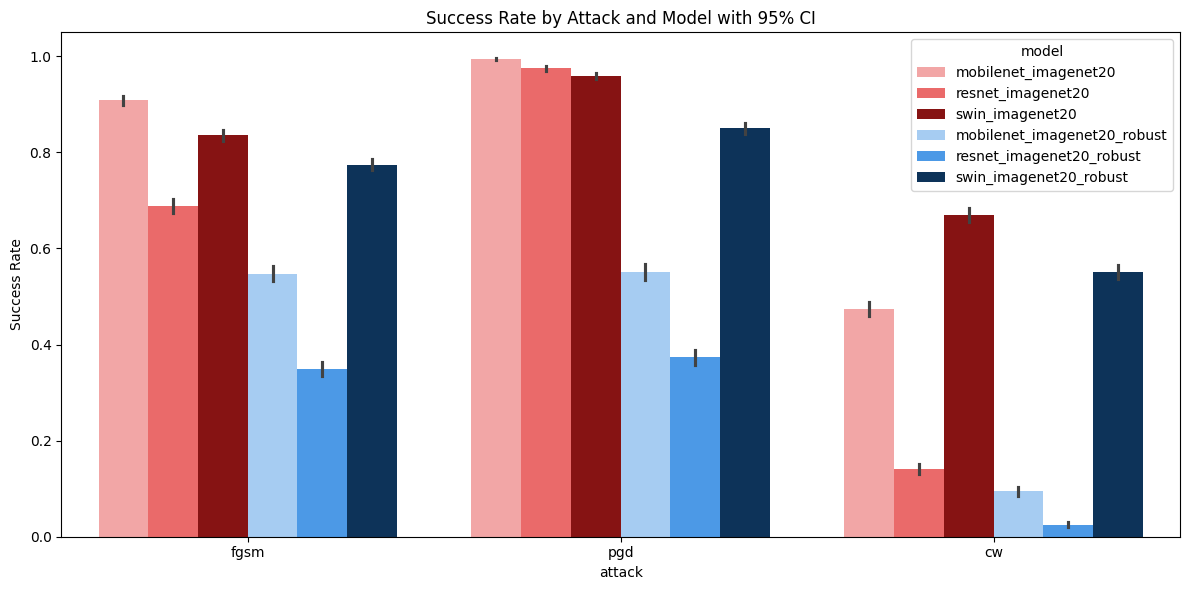

In [ ]:
# Define the order of your models 
model_order = [
    "mobilenet_imagenet20",
    "resnet_imagenet20",
    "swin_imagenet20",
    "mobilenet_imagenet20_robust",
    "resnet_imagenet20_robust",
    "swin_imagenet20_robust"
]

# Create a custom color palette
custom_palette = {
    "mobilenet_imagenet20": "#FF9999",          # light red
    "resnet_imagenet20": "#FF5555",             # medium red
    "swin_imagenet20": "#990000",               # dark red
    "mobilenet_imagenet20_robust": "#99CCFF",   # light blue
    "resnet_imagenet20_robust": "#3399FF",      # medium blue
    "swin_imagenet20_robust": "#003366",        # dark blue
}

# Plot with Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_total, 
    x="attack",
    y="attack_successful",
    hue="model",
    errorbar=('ci', 95),
    estimator=lambda x: x.mean(),
    palette=custom_palette,
    hue_order=model_order
)

plt.title("Success Rate by Attack and Model with 95% CI")
plt.ylabel("Success Rate")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()



# Statistical tests

In [71]:
psnr_robust = df_models.groupby('attack')['psnr_score'].mean()
print(psnr_robust)

attack
cw      72.672418
fgsm    85.295767
pgd     86.761329
Name: psnr_score, dtype: float64


In [72]:
psnr_base = df_base.groupby('attack')['psnr_score'].mean()
print(psnr_base)

attack
cw      75.263213
fgsm    85.846883
pgd     91.256196
Name: psnr_score, dtype: float64


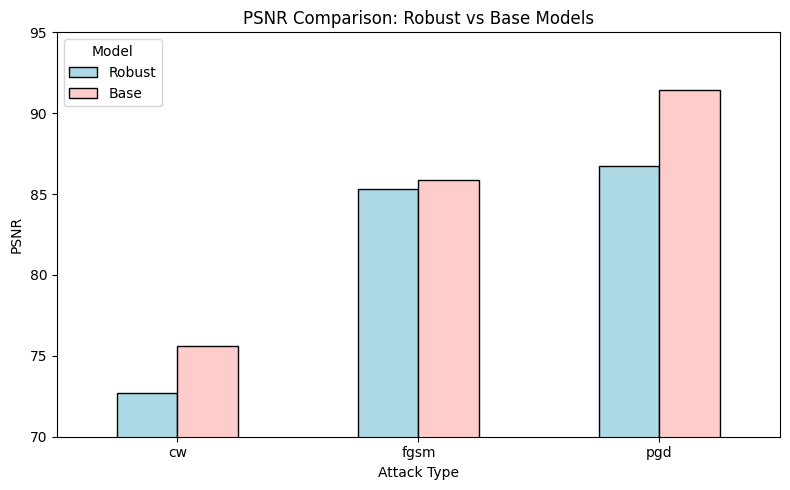

In [ ]:
psnr_robust = pd.Series({
    'cw': 72.672418,
    'fgsm': 85.295767,
    'pgd': 86.761329
}, name="Robust")

psnr_success = pd.Series({
    'cw': 75.583,
    'fgsm': 85.875,
    'pgd': 91.445
}, name="Base")

# Combine
df = pd.concat([psnr_robust, psnr_success], axis=1)
df.columns = ["Robust", "Base"]

# Plotting
ax = df.plot(
    kind="bar", 
    figsize=(8, 5), 
    color=["#ADD8E6", "#FFCCCC"],  # Light blue and light red
    edgecolor="black"
)

# Formatting
plt.title("PSNR Comparison: Robust vs Base Models")
plt.ylabel("PSNR")
plt.xlabel("Attack Type")
plt.xticks(rotation=0)
plt.ylim(70, 95)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [ ]:
model = smf.mixedlm(
    "psnr_score ~ model * attack",     
    df_models,
    groups="dataset_index"                  
)
result = model.fit()

# Print the summary
print(result.summary())


                            Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             psnr_score 
No. Observations:             35424               Method:                         REML       
No. Groups:                   3936                Scale:                          0.7236     
Min. group size:              9                   Log-Likelihood:                 -45582.9996
Max. group size:              9                   Converged:                      Yes        
Mean group size:              9.0                                                            
---------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                        72.528    0.014 5157.397 0.000 72.501 7

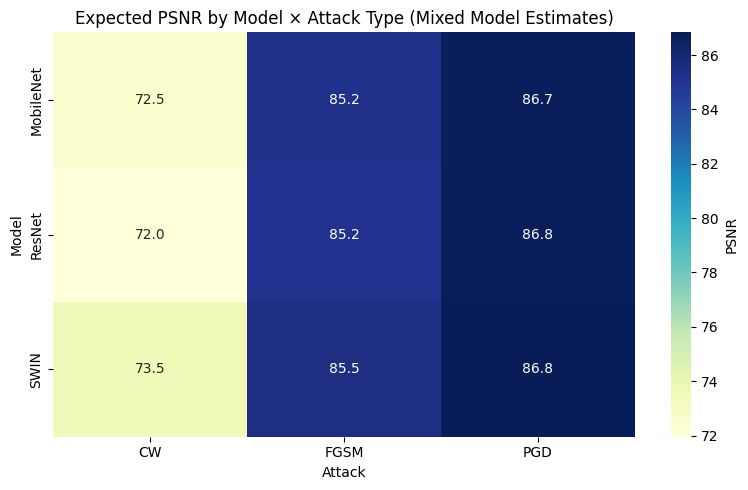

In [ ]:
data = [
    [72.528, 85.228, 86.685],  # MobileNet
    [71.958, 85.198, 86.765],  # ResNet
    [73.531, 85.461, 86.835],  # SWIN
]

# Labels
models = ['MobileNet', 'ResNet', 'SWIN']
attacks = ['CW', 'FGSM', 'PGD']

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'PSNR'})
plt.title('Expected PSNR by Model × Attack Type (Mixed Model Estimates)')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


In [ ]:
model = smf.mixedlm(
    "psnr_score ~ model * attack",     
    df_total,
    groups="dataset_index"                
)
result = model.fit()

# Print the summary
print(result.summary())


                             Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             psnr_score  
No. Observations:               70848               Method:                         REML        
No. Groups:                     3936                Scale:                          1.1055      
Min. group size:                18                  Log-Likelihood:                 -106700.4435
Max. group size:                18                  Converged:                      Yes         
Mean group size:                18.0                                                            
------------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.    z     P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                           75.583  

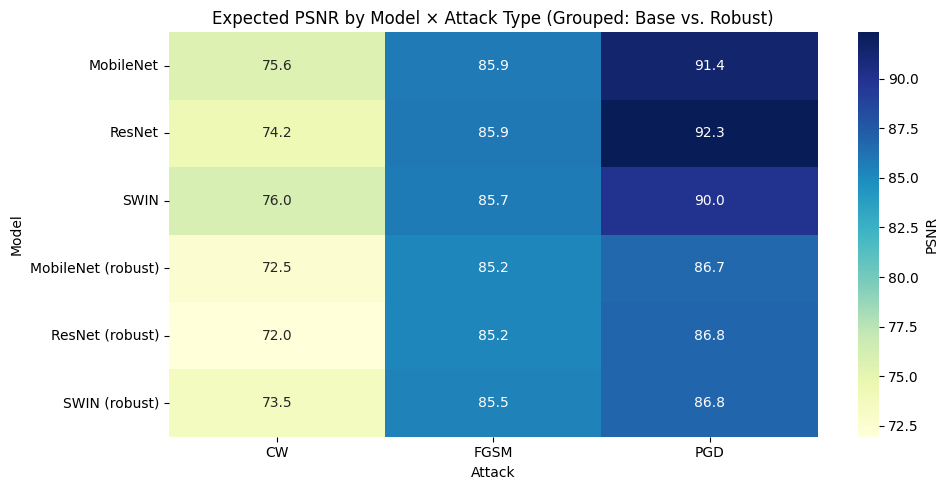

In [ ]:
# PSNR values
data = {
    "MobileNet":         [75.583, 85.875, 91.445],
    "ResNet":            [74.227, 85.928, 92.326],
    "SWIN":              [75.981, 85.740, 89.999],
    "MobileNet (robust)": [72.529, 85.230, 86.686],
    "ResNet (robust)":    [71.959, 85.199, 86.766],
    "SWIN (robust)":      [73.531, 85.461, 86.835],
}
attacks = ['CW', 'FGSM', 'PGD']

# Create DataFrame and transpose
df = pd.DataFrame(data, index=attacks)
df = df[["MobileNet", "ResNet", "SWIN", "MobileNet (robust)", "ResNet (robust)", "SWIN (robust)"]]

# Plot
plt.figure(figsize=(10, 5))
sns.heatmap(df.T, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'PSNR'})
plt.title('Expected PSNR by Model × Attack Type (Grouped: Base vs. Robust)')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


# KL divergence

In [35]:
df_total["original_probs"] = df_total["original_probs"].apply(ast.literal_eval)
df_total["adversarial_probs"] = df_total["adversarial_probs"].apply(ast.literal_eval)

In [36]:
def kl_divergence(p, q):
    # Convert to tensors
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    p = p + epsilon
    q = q + epsilon

    return F.kl_div(q.log(), p, reduction="sum").item()  

In [38]:
df_total["kl_divergence"] = df_total.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


In [40]:
print(df_total.groupby("attack")["kl_divergence"].mean())

attack
cw      1.917062
fgsm    3.461984
pgd     5.780550
Name: kl_divergence, dtype: float64


In [42]:
model = smf.mixedlm("kl_divergence ~ model * attack", data=df_total, groups=df_total["dataset_index"])
result = model.fit()

print(result.summary())

                             Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             kl_divergence
No. Observations:             70848               Method:                         REML         
No. Groups:                   3936                Scale:                          9.2762       
Min. group size:              18                  Log-Likelihood:                 -182608.2101 
Max. group size:              18                  Converged:                      Yes          
Mean group size:              18.0                                                             
-----------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                            2.101    0.054  

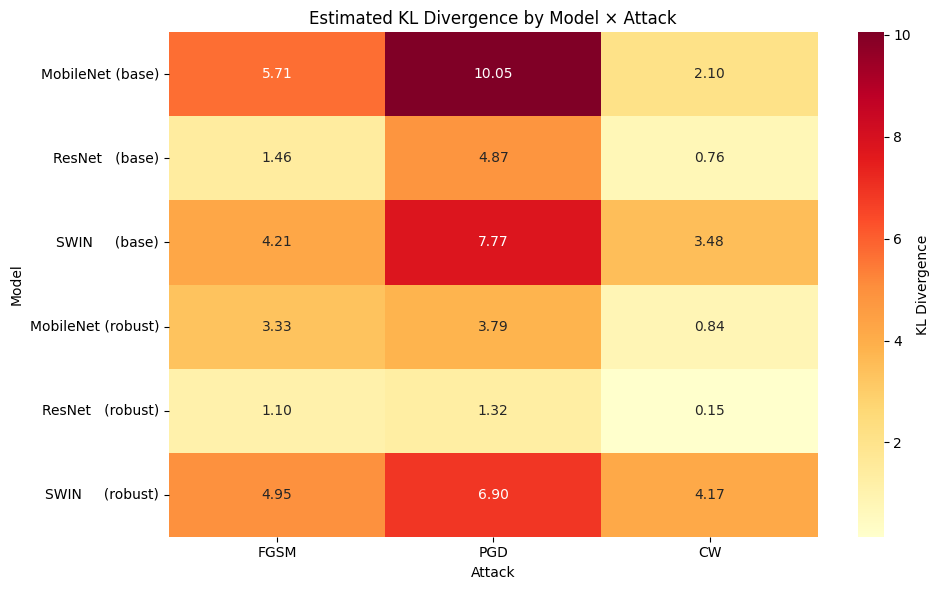

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstructed KL divergence
data = [
    [ 5.708, 10.048, 2.101],  # MobileNet (base)
    [ 1.462,  4.865, 0.760],  # ResNet (base)
    [ 4.213,  7.768, 3.484],  # SWIN   (base)
    [ 3.332,  3.788, 0.836],  # MobileNet (robust)
    [ 1.102,  1.316, 0.150],  # ResNet   (robust)
    [ 4.951,  6.896, 4.169],  # SWIN     (robust)
]

models = [
    "MobileNet (base)",
    "ResNet   (base)",
    "SWIN     (base)",
    "MobileNet (robust)",
    "ResNet   (robust)",
    "SWIN     (robust)",
]

#column order: FGSM, PGD, CW
attacks = ["FGSM", "PGD", "CW"]

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "KL Divergence"},
)
plt.title("Estimated KL Divergence by Model × Attack")
plt.ylabel("Model")
plt.xlabel("Attack")
plt.tight_layout()
plt.show()
